In [1]:
import torch
from models.Week7EGNN import JetFlowMatcher
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
initial_model_info = torch.load("downloaded_output/models/model_initial.pth", map_location=device, weights_only=False)
final_model_info = torch.load("downloaded_output/models/final_model.pth", map_location=device, weights_only=False)
final_model_info

OrderedDict([('time_embedding.fc1.weight',
              tensor([[ 0.0151, -0.0075,  0.0076,  ..., -0.0095,  0.0016, -0.0095],
                      [ 0.0009, -0.0114, -0.0275,  ..., -0.0070, -0.0124,  0.0233],
                      [-0.0082,  0.0025,  0.0276,  ...,  0.0073, -0.0213, -0.0130],
                      ...,
                      [-0.0067,  0.0388, -0.0193,  ...,  0.0005,  0.0838,  0.0368],
                      [ 0.0014,  0.0063,  0.0118,  ...,  0.0148, -0.0140, -0.0019],
                      [-0.0106, -0.0152,  0.0104,  ...,  0.0169,  0.0051, -0.0045]])),
             ('time_embedding.fc1.bias',
              tensor([ 0.0035,  0.0022, -0.0053,  0.0109, -0.0421, -0.0095,  0.0075, -0.2012,
                      -0.4142,  0.0219, -0.0085, -0.0015, -0.0164, -0.0217,  0.0054,  0.0015,
                      -0.0074, -0.0238,  0.0992,  0.0163,  0.3616, -0.0084, -0.0027, -0.0058,
                       0.0043,  0.0010, -0.0046,  0.0099,  0.0127, -0.0228,  0.0220,  0.0084])),
   

In [3]:
final_model = JetFlowMatcher(
    max_num_jet_types=5, 
    num_layers=4,
    hidden_dim=128
)
initial_model = JetFlowMatcher(
    max_num_jet_types=5,
    num_layers=4,
    hidden_dim=128
)
initial_model.load_state_dict(initial_model_info)
final_model.load_state_dict(final_model_info)

<All keys matched successfully>

In [4]:
import pickle
with open(f"downloaded-data/x_test.pkl", "rb") as f:
    X_test = pickle.load(f)
X_test_samples = X_test[:1000][:][0]
X_test_samples.shape

/Users/arjunsharma/development/s25-fermilab-research/src/venv/lib/python3.10/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


torch.Size([1000, 150, 4])

In [5]:
torch.linspace(0, 1, 2).to(device)

tensor([0., 1.])

In [8]:
torch.manual_seed(42)
from util import jet_attributes
jet_attr_generator = jet_attributes.load_model().to(device)

n_samples = 100
n_particles = 150
n_features = 4


with torch.no_grad():
    final_model.eval()
    jet_attr_generator.eval()
    x = torch.randn(
        (n_samples, n_particles, n_features),
        device=device
    )
    x_model_final = x.clone()
    x_model_initial = x.clone()
    x0 = x.clone()
    n_jet_types = 3
    generated_jet_attrs, _ = jet_attributes.generate_jets(jet_attr_generator, device, n_jet_types=n_jet_types, num_jets=x.shape[0])
    jet_one_hot_enc = generated_jet_attrs[:, :5].to(device)
    n_gen_particles = generated_jet_attrs[:, -1].long().to(device)

    masks = jet_attributes.generate_masks(
        n_gen_particles,
        max_n_particles=n_particles,
        device=device
    )
    generated_jet_attrs = torch.cat([
        jet_one_hot_enc,
        n_gen_particles.unsqueeze(-1).float()
    ], dim=-1)

    # Add 1 extra because we want to stop at t = 1
    times = torch.linspace(0, 1, 16 + 1).to(device) 
    for i in range(len(times) - 1):
        t = times[i].unsqueeze(0).repeat(n_samples).to(device)
        initial_field = initial_model.forward(x_model_initial, t, generated_jet_attrs, masks)
        final_field = final_model.forward(x_model_final, t, generated_jet_attrs, masks)

        plt.clf()
        colors = sns.color_palette("deep", n_colors=3)
        sns.set_palette("deep")

        final_field_flat = final_field[:, :, :2].flatten(start_dim=0, end_dim=1)[:1000]
        final_field_flat = final_field_flat * (times[i+1] - times[i])
        field_field = final_field_flat.cpu().numpy()
        initial_field_flat = initial_field[:, :, :2].flatten(start_dim=0, end_dim=1)[:1000]
        initial_field_flat = initial_field_flat * (times[i+1] - times[i])
        initial_field_flat = initial_field_flat.cpu().numpy()
        colors = sns.color_palette("deep")

        plt.scatter(
            x_model_final[:, :, 0].flatten()[:1000].cpu().numpy(),
            x_model_final[:, :, 1].flatten()[:1000].cpu().numpy(),
            label="Current data distribution",
            alpha=0.75,
            color=colors[3],
            s=0.5
        )

        plt.quiver(
            x_model_final[:, :, 0].flatten()[:1000].cpu().numpy(),
            x_model_final[:, :, 1].flatten()[:1000].cpu().numpy(),
            final_field_flat[:, 0],
            final_field_flat[:, 1],
            label="Final model vector field",
            alpha=0.75,
            color=colors[0]
        )

        plt.quiver(
            x_model_initial[:, :, 0].flatten()[:1000].cpu().numpy(),
            x_model_initial[:, :, 1].flatten()[:1000].cpu().numpy(),
            initial_field_flat[:, 0],
            initial_field_flat[:, 1],
            label="Initial model vector field",
            alpha=0.75,
            color=colors[1]
        )

        sns.scatterplot(
        x=X_test_samples[:, 0].cpu().numpy().flatten(),
        y=X_test_samples[:, 1].cpu().numpy().flatten(),
        label="Test data",
        alpha=0.75,
        color=colors[2]
        )

        plt.xlabel(r"$E/c$ ")
        plt.ylabel(r"$p_x$")
        plt.title(r"$t=%.2f \rightarrow t=%.2f$" % (times[i].item(), times[i+1].item()))

        plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
        plt.savefig(f"debugging/field_vectors_{i}.png", bbox_inches='tight', dpi=300)

        plt.xlim(-1, 1)
        plt.ylim(-1, 1)
        plt.savefig(f"debugging/field_vectors_zoomed_{i}.png", bbox_inches='tight', dpi=300)

        plt.clf()

        print(f"{x_model_final.mean()=}, {x_model_final.std()=}")
        print(f"{x_model_initial.mean()=}, {x_model_initial.std()=}")

        x_model_final = x_model_final + (final_field * (times[i+1] - times[i]))
        x_model_initial = x_model_initial + (initial_field * (times[i+1] - times[i]))
        print(f"{x_model_final.mean()=}, {x_model_final.std()=}")
        print(f"{x_model_initial.mean()=}, {x_model_initial.std()=}")

x_model_final.mean()=tensor(0.0016), x_model_final.std()=tensor(1.0053)
x_model_initial.mean()=tensor(0.0016), x_model_initial.std()=tensor(1.0053)
x_model_final.mean()=tensor(0.0016), x_model_final.std()=tensor(0.9805)
x_model_initial.mean()=tensor(0.0016), x_model_initial.std()=tensor(1.0054)
x_model_final.mean()=tensor(0.0016), x_model_final.std()=tensor(0.9805)
x_model_initial.mean()=tensor(0.0016), x_model_initial.std()=tensor(1.0054)
x_model_final.mean()=tensor(0.0016), x_model_final.std()=tensor(0.9590)
x_model_initial.mean()=tensor(0.0016), x_model_initial.std()=tensor(1.0054)
x_model_final.mean()=tensor(0.0016), x_model_final.std()=tensor(0.9590)
x_model_initial.mean()=tensor(0.0016), x_model_initial.std()=tensor(1.0054)
x_model_final.mean()=tensor(0.0017), x_model_final.std()=tensor(0.9403)
x_model_initial.mean()=tensor(0.0016), x_model_initial.std()=tensor(1.0055)
x_model_final.mean()=tensor(0.0017), x_model_final.std()=tensor(0.9403)
x_model_initial.mean()=tensor(0.0016), x

<Figure size 640x480 with 0 Axes>

In [13]:
"ffmpeg -r 7 -i field_vectors_zoomed_%%01d.png -vcodec mpeg4 -y movie_zoomed_in.mp4".split(" ")

['ffmpeg',
 '-r',
 '7',
 '-i',
 'field_vectors_zoomed_%%01d.png',
 '-vcodec',
 'mpeg4',
 '-y',
 'movie_zoomed_in.mp4']

In [ ]:
import subprocess
subprocess.run("ffmpeg -r 7 -i debugging/field_vectors_zoomed_%01d.png -vcodec mpeg4 -y debugging/movie_zoomed_in.mp4".split(" "))
subprocess.run("ffmpeg -r 7 -i debugging/field_vectors_%01d.png -vcodec mpeg4 -y debugging/movie_zoomed_out.mp4".split(" "))

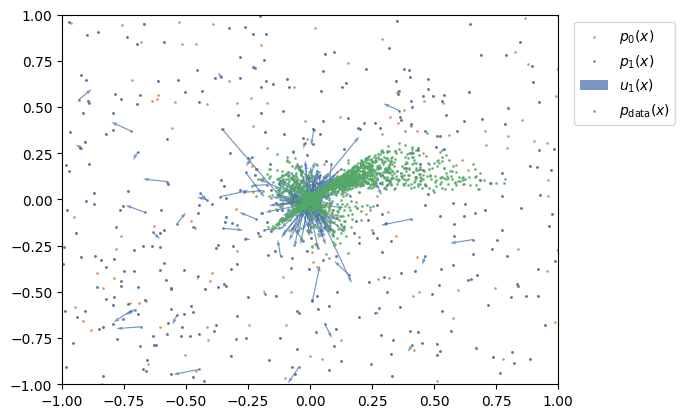

In [11]:
plt.scatter(
    x0[:, :, 0].flatten()[:1000].cpu().numpy(),
    x0[:, :, 1].flatten()[:1000].cpu().numpy(),
    s=1,
    alpha=0.75,
    color=colors[1],
    label=r"$p_0(x)$"
)


plt.scatter(
    x_model_final[:, :, 0].flatten()[:1000].cpu().numpy(),
    x_model_final[:, :, 1].flatten()[:1000].cpu().numpy(),
    s=1,
    alpha=0.75,
    color=colors[0],
    label=r"$p_1(x)$"
)

plt.quiver(
    x_model_final[:, :, 0].flatten()[:1000].cpu().numpy(),
    x_model_final[:, :, 1].flatten()[:1000].cpu().numpy(),
    final_field_flat[:, 0],
    final_field_flat[:, 1],
    label=r"$u_1(x)$",
    alpha=0.75,
    color=colors[0]
)

plt.scatter(
    X_test_samples[:, 0].cpu().numpy().flatten(),
    X_test_samples[:, 1].cpu().numpy().flatten(),
    alpha=0.75,
    color=colors[2],
    s=1,
    label=r"$p_\text{data}(x)$"
)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1))
plt.savefig("debugging/field_vectors_final.png", bbox_inches="tight", dpi=300)